In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [5]:
train_dir = "train"
test_dir1 = "test1"
test_dir2 = "test2"

In [6]:
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset1 = datasets.ImageFolder(test_dir1, transform=transform)
test_dataset2 = datasets.ImageFolder(test_dir2, transform=transform)

In [7]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader1 = DataLoader(test_dataset1, batch_size=batch_size, shuffle=False)
test_loader2 = DataLoader(test_dataset2, batch_size=batch_size, shuffle=False)
class_names = ["red", "blue", "yellow"]

In [19]:
class ConeNet(nn.Module):
    def __init__(self, num_classes=3):
        super(ConeNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)       # 卷积输出: [batch, channel, H, W]
        x = torch.flatten(x, 1)# 从第1维开始展平 -> [batch, 特征总数]
        x = self.fc(x)
        return x


In [20]:
device = torch.device("cuda:0" )
model = ConeNet().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [21]:
epochs = 5

In [22]:
loss_list = []

In [25]:
for epoch in range(epochs):
    model.train()
    num_batches = len(train_loader)
    half_batch = num_batches // 2

    for batch_idx, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)

        # 1. 前向传播，计算损失
        pred = model(x)
        loss = loss_fn(pred, y)

        # 记录当前批次损失
        loss_list.append(loss.item())

        # 一轮训练一半时：前向完成、反向未开始，打印损失
        if batch_idx + 1 == half_batch:
            print(f"Train Epoch : {epoch+1:<3}        Loss : {loss.item():.6f}")

        # 2. 反向传播 + 参数更新
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # 本轮最后一个批次损失打印
    print(f"Train Epoch : {epoch+1:<3}        Loss : {loss.item():.6f}")

    # 测试集评估
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for x, y in test_loader1:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = loss_fn(pred, y)
            test_loss += loss.item()

            _, predicted = torch.max(pred.data, 1)
            test_total += y.size(0)
            test_correct += (predicted == y).sum().item()

    avg_test_loss = test_loss / len(test_loader1)
    test_acc = 100 * test_correct / test_total
    print(f"Test -- Average Loss : {avg_test_loss:.4f}, Accuracy : {test_acc:.3f}\n")


Train Epoch : 1          Loss : 0.789824
Train Epoch : 1          Loss : 0.688138
Test -- Average Loss : 0.6372, Accuracy : 71.429

Train Epoch : 2          Loss : 0.306638
Train Epoch : 2          Loss : 0.180579
Test -- Average Loss : 0.4012, Accuracy : 86.175

Train Epoch : 3          Loss : 0.221212
Train Epoch : 3          Loss : 0.000000
Test -- Average Loss : 0.1978, Accuracy : 93.088

Train Epoch : 4          Loss : 0.018882
Train Epoch : 4          Loss : 0.036618
Test -- Average Loss : 0.1398, Accuracy : 95.392

Train Epoch : 5          Loss : 0.024805
Train Epoch : 5          Loss : 0.000000
Test -- Average Loss : 0.0684, Accuracy : 98.618



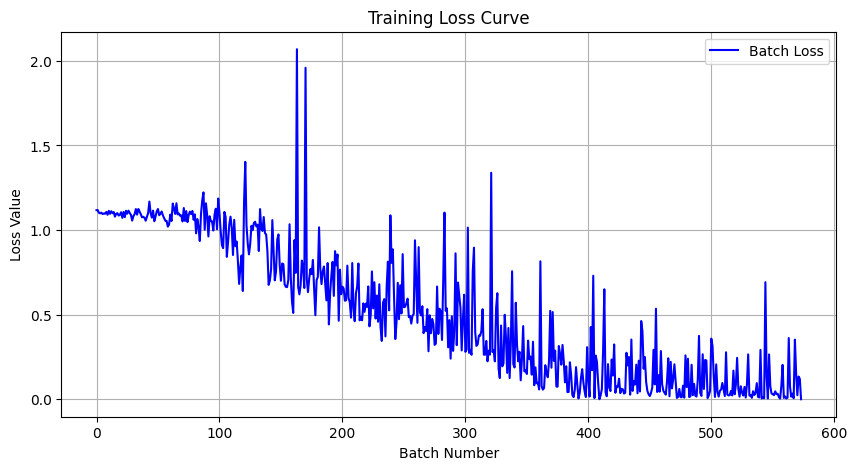

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(loss_list, label='Batch Loss', color='blue')
plt.xlabel('Batch Number')
plt.ylabel('Loss Value')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
print("test Overall Accuracy:", end="")
model.eval()
test_total = 0
test_correct = 0
class_total = [0, 0, 0]
class_correct = [0, 0, 0]

with torch.no_grad():
    for x, y in test_loader1:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        _, predicted = torch.max(pred, 1)

        test_total += y.size(0)
        test_correct += (predicted == y).sum().item()

        for label, p in zip(y, predicted):
            label = label.item()
            p = p.item()
            class_total[label] += 1
            if label == p:
                class_correct[label] += 1

total_acc = 100 * test_correct / test_total
print(f"{total_acc:.3f}%")

for i, cls_name in enumerate(class_names):
    if class_total[i] == 0:
        print(f"Category Accuracy :    {cls_name} : 0.000 %")
    else:
        cls_acc = 100 * class_correct[i] / class_total[i]
        print(f"Category Accuracy :    {cls_name} : {cls_acc:.3f} %")


test Overall Accuracy:98.618%
Category Accuracy :    red : 100.000 %
Category Accuracy :    blue : 97.531 %
Category Accuracy :    yellow : 98.113 %


In [30]:
loss_list1 = []

In [33]:
for epoch in range(epochs):
    model.train()
    num_batches = len(train_loader)
    half_batch = num_batches // 2

    for batch_idx, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)

        # 1. 前向传播，计算损失
        pred = model(x)
        loss = loss_fn(pred, y)

        # 记录当前批次损失
        loss_list1.append(loss.item())

        # 一轮训练一半时：前向完成、反向未开始，打印损失
        if batch_idx + 1 == half_batch:
            print(f"Train Epoch : {epoch+1:<3}        Loss : {loss.item():.6f}")

        # 2. 反向传播 + 参数更新
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # 本轮最后一个批次损失打印
    print(f"Train Epoch : {epoch+1:<3}        Loss : {loss.item():.6f}")

    # 测试集评估
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for x, y in test_loader2:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = loss_fn(pred, y)
            test_loss += loss.item()

            _, predicted = torch.max(pred.data, 1)
            test_total += y.size(0)
            test_correct += (predicted == y).sum().item()

    avg_test_loss = test_loss / len(test_loader2)
    test_acc = 100 * test_correct / test_total
    print(f"Test -- Average Loss : {avg_test_loss:.4f}, Accuracy : {test_acc:.3f}\n")


Train Epoch : 1          Loss : 0.004131
Train Epoch : 1          Loss : 0.000154
Test -- Average Loss : 0.2532, Accuracy : 94.286

Train Epoch : 2          Loss : 0.014118
Train Epoch : 2          Loss : 0.000768
Test -- Average Loss : 0.2031, Accuracy : 94.286

Train Epoch : 3          Loss : 0.035377
Train Epoch : 3          Loss : 0.000351
Test -- Average Loss : 0.3581, Accuracy : 91.429

Train Epoch : 4          Loss : 0.032992
Train Epoch : 4          Loss : 0.000000
Test -- Average Loss : 0.1543, Accuracy : 97.857

Train Epoch : 5          Loss : 0.005582
Train Epoch : 5          Loss : 0.000871
Test -- Average Loss : 0.1700, Accuracy : 92.143



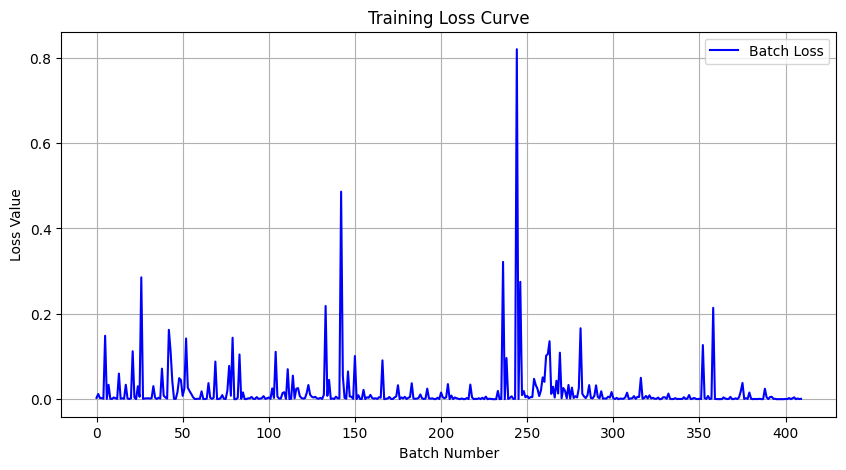

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(loss_list1, label='Batch Loss', color='blue')
plt.xlabel('Batch Number')
plt.ylabel('Loss Value')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
print("test Overall Accuracy:", end="")
model.eval()
test_total = 0
test_correct = 0
class_total = [0, 0, 0]
class_correct = [0, 0, 0]

with torch.no_grad():
    for x, y in test_loader2:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        _, predicted = torch.max(pred, 1)

        test_total += y.size(0)
        test_correct += (predicted == y).sum().item()

        for label, p in zip(y, predicted):
            label = label.item()
            p = p.item()
            class_total[label] += 1
            if label == p:
                class_correct[label] += 1

total_acc = 100 * test_correct / test_total
print(f"{total_acc:.3f}%")

for i, cls_name in enumerate(class_names):
    if class_total[i] == 0:
        print(f"Category Accuracy :    {cls_name} : 0.000 %")
    else:
        cls_acc = 100 * class_correct[i] / class_total[i]
        print(f"Category Accuracy :    {cls_name} : {cls_acc:.3f} %")


test Overall Accuracy:92.143%
Category Accuracy :    red : 100.000 %
Category Accuracy :    blue : 81.633 %
Category Accuracy :    yellow : 95.122 %
